In [1]:
import pdfs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import importlib
import cupy as cp

In [2]:
from eryn.backends import HDFBackend
import corner
import json

corner_defaults = dict(
    color='darkred',
    plot_points=False,
    levels=[0.68, 0.90],
    show_titles=True, 
    title_kwargs={"fontsize": 15}, 
    label_kwargs={"fontsize": 15},
    density=True,
    smooth=0.9, 
    fill_contours=True,
    bins=20, 
    title_fmt='.2f', 
    hist_bin_factor=1,
    quantiles=[0.05, 0.5, 0.95]
)

In [ ]:

importlib.reload(pdfs)

<module 'pdfs' from '/data/aqc/rjmcmc_pop/pdfs.py'>

## model testing

### skew -t

0.9995238865088271
0.9999853164303235
1.0000000467042085
1.000002703379394


(0.0, 0.3899376460289639)

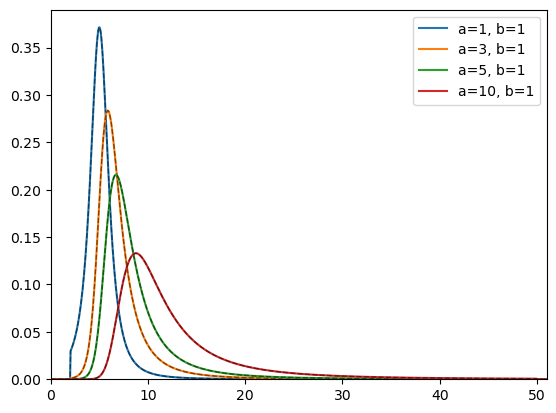

In [4]:
xx = np.linspace(0, 51, 1000)
b = 1
loc = 5
xmin, xmax= 2, 50
for a in (1, 3, 5, 10):
    yy = pdfs.jf_skew_t.pdf(xx, a, b, loc=loc, xmin=xmin, xmax=xmax)
    plt.plot(xx, yy, label=f'a={a}, b={b}')
    print(np.trapz(yy, xx)) # check normalization

    # check logpdf
    plt.plot(xx, np.exp(pdfs.jf_skew_t.logpdf(xx, a, b, loc=loc, xmin=xmin, xmax=xmax)), color='k', lw=1, alpha=0.5, ls='--')

plt.legend()
plt.xlim(0, 51)
plt.ylim(bottom=0)


### powerlaw

In [8]:
importlib.reload(pdfs)

<module 'pdfs' from '/data/aqc/rjmcmc_pop/scripts/pdfs.py'>

1.0001519447390743
1.0005669058192617
1.0014428311776793


(0.0, 1.2089505337109963)

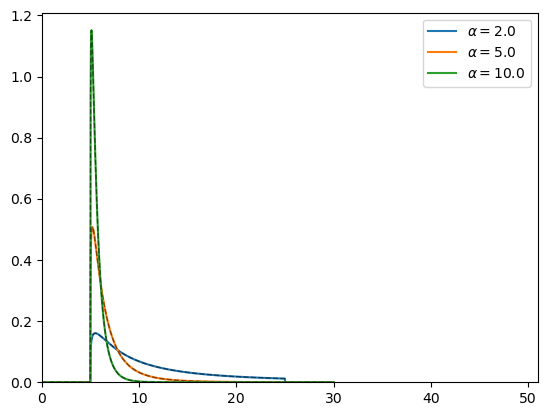

In [13]:
xx = np.linspace(0, 30, 1000)
p = 5.
xmin, xmax= 5., 25.
for alpha in (2.,5.,10.):
    yy = pdfs.smoothed_powerlaw.pdf(xx, alpha, xmin=xmin, xmax=xmax, p=p)
    plt.plot(xx, yy, label=f'$\\alpha={alpha}$')
    print(np.trapz(yy,xx))
    plt.plot(xx, np.exp(pdfs.smoothed_powerlaw.logpdf(xx, alpha, xmin=xmin, xmax=xmax, p=p)), color='k', lw=1, alpha=0.5, ls='--')

plt.legend()
plt.xlim(0, 51)
plt.ylim(bottom=0)


In [36]:
sns.dark_palette('pink', 5, reverse=True)

[(np.float64(1.0),
  np.float64(0.7529411764705882),
  np.float64(0.796078431372549)),
 (np.float64(0.7958552533314668),
  np.float64(0.5976965840041064),
  np.float64(0.632261252885213)),
 (np.float64(0.5917105066629336),
  np.float64(0.44245199153762466),
  np.float64(0.46844407439787705)),
 (np.float64(0.38756575999440035),
  np.float64(0.28720739907114284),
  np.float64(0.3046268959105411)),
 (np.float64(0.186610774992563),
  np.float64(0.13438850336194982),
  np.float64(0.14336936083706975))]

(0.0, 0.5392830658196223)

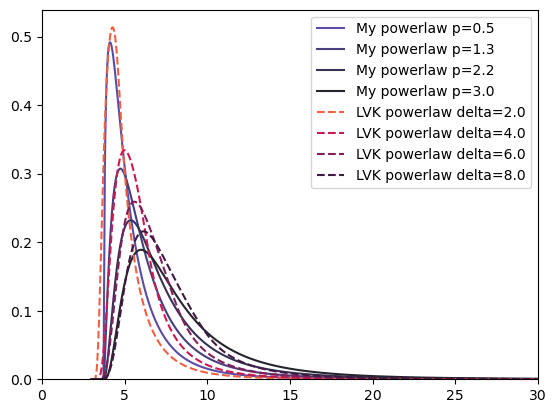

In [37]:
## compare to LVK taper

alpha = 5.
p = 0.5
delta = 5.
xmin, xmax = 3, 30

xx = cp.linspace(xmin, xmax, 1000)

n_plot = 4

# nice integrable plaw
for p, color in zip(np.linspace(0.5, 3, n_plot, endpoint=True), sns.dark_palette('slateblue', n_plot+1, reverse=True)[1:]):
    plt.plot(xx.get(), pdfs.smoothed_powerlaw.pdf(xx, alpha, xmin=1.25*xmin, xmax=xmax, p=p).get(), label=f'My powerlaw p={p:.1f}', color=color)

# LVK powerlaw
for delta, color in zip(np.linspace(2,8,n_plot,endpoint=True), sns.color_palette('rocket_r', n_plot+1)[1:]):
    plt.plot(xx.get(), pdfs.LVK_Plancktaper_powerlaw.pdf(xx, alpha, xmin=xmin, xmax=xmax, delta=delta).get(), label=f'LVK powerlaw delta={delta}',ls='--', color=color)

plt.legend()

plt.xlim(0,xmax)
plt.ylim(bottom=0)

In [12]:
pdfs.smoothed_powerlaw.pdf(50.0, xmin=1.0, xmax=100.0, alpha=2.0, p=2.0)

array(0.00118776)

In [9]:
test_hp_vals = {'xmax': 300.0, 'alpha': cp.array([[7.3766587 ],
       [9.7908431 ],
       [9.58054041],
       [1.387173  ],
       [8.51659009],
       [6.69491163],
       [3.00183083],
       [4.04845836],
       [2.77330628],
       [8.57679733],
       [6.5039141 ],
       [6.73520477],
       [9.49743287],
       [4.58072076],
       [2.69394613],
       [9.48273438],
       [8.55147174],
       [6.01421169],
       [9.40774909],
       [5.9331369 ]]), 'p': cp.array([[2.35025296],
       [2.72493224],
       [2.97681718],
       [1.08576279],
       [3.26971034],
       [2.540945  ],
       [0.91871608],
       [1.3875807 ],
       [1.69361895],
       [1.61671497],
       [2.01663972],
       [1.64970777],
       [1.62577852],
       [1.92550665],
       [0.64455248],
       [3.22712957],
       [1.71537627],
       [0.54969308],
       [3.37381674],
       [3.14159318]]), 'xmin': cp.array([[2.44702941],
       [3.9937229 ],
       [3.13202255],
       [3.88384453],
       [3.03501712],
       [3.51630717],
       [3.79720302],
       [2.78361364],
       [3.56430851],
       [3.56789527],
       [2.7225717 ],
       [2.96795953],
       [3.03791826],
       [3.35023074],
       [2.29573165],
       [2.31476863],
       [3.97701318],
       [3.00272914],
       [3.69178041],
       [3.56619755]])}

In [11]:
res = pdfs.smoothed_powerlaw.pdf(cp.linspace(10, 200, 100), **test_hp_vals)
res

array([[1.96937491e-03, 6.07835315e-04, 2.19494620e-04, ...,
        1.07844249e-12, 1.00399299e-12, 9.35325372e-13],
       [1.00152603e-02, 2.36869714e-03, 6.60126755e-04, ...,
        8.39120025e-15, 7.63243417e-15, 6.94858887e-15],
       [2.51593272e-03, 5.77856379e-04, 1.59591112e-04, ...,
        3.03165908e-15, 2.76295325e-15, 2.52030670e-15],
       ...,
       [2.92210921e-03, 1.05458714e-03, 4.40582011e-04, ...,
        5.93199911e-11, 5.59508554e-11, 5.28027932e-11],
       [1.18413520e-02, 3.07637338e-03, 9.25788816e-04, ...,
        3.63121559e-14, 3.31546836e-14, 3.02981446e-14],
       [4.68902770e-02, 2.16441236e-02, 1.06936919e-02, ...,
        3.78887982e-09, 3.57822873e-09, 3.38113514e-09]], shape=(20, 100))

In [17]:
bad_hp_vals = {k: v[11] for k, v in test_hp_vals.items() if isinstance(v, np.ndarray)}
res_bad = pdfs.smoothed_powerlaw.pdf(test_mass_value, xmax=300.0, alpha=1.1, p=3.58246245, xmin=3.51139592)
res_bad

array([0.01087637, 0.0118524 , 0.01184591, 0.01181635, 0.01095269,
       0.01072022])

In [16]:
bad_hp_vals

{'alpha': array([0.95596987]),
 'p': array([3.58246245]),
 'xmin': array([3.51139592])}

In [7]:
res.shape

(20, 6)

In [13]:
np.nonzero(np.isnan(res))

(array([11, 11, 11, 11, 11, 11]), array([0, 1, 2, 3, 4, 5]))

### rate

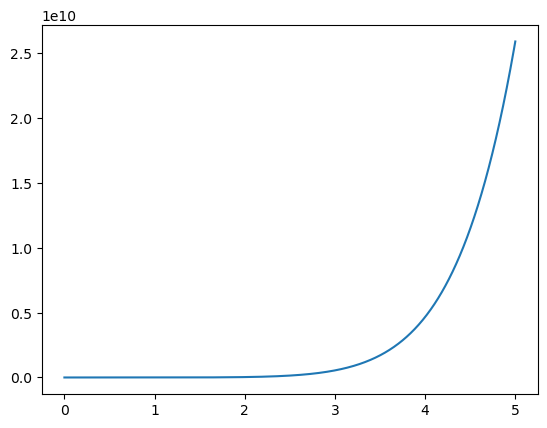

In [5]:
zz = np.linspace(0, 5, 1000)
rate_model = pdfs.PL_rate()

plt.plot(zz, rate_model.pdf(zz, gamma=11.))


In [6]:
rate_model.pdf(
    np.array([0.15958595, 0.20250603, 0.16670703, 0.14065192, 0.29049836,
       0.24088094]),
    gamma = np.array([[-3.60699875],
       [ 1.31015412],
       [ 1.7218555 ],
       [-3.54534101],
       [ 3.95390699]])
)

array([[ 11.98643694,  15.60862566,  12.62372855,  10.24286272,
         21.09881746,  18.34146603],
       [ 24.82432873,  38.65146676,  26.94319701,  19.56374791,
         73.93830021,  53.00530576],
       [ 26.38463707,  41.70018829,  28.70895591,  20.65294949,
         82.12369097,  57.93061797],
       [ 12.0963649 ,  15.78711108,  12.74431101,  10.32631301,
         21.43320754,  18.58716837],
       [ 36.71796539,  62.9356773 ,  40.50229351,  27.70453242,
        145.10581171,  93.78180808]])

In [13]:
import scipy.special as sc

In [19]:
importlib.reload(pdfs)

<module 'pdfs' from '/data/aqc/rjmcmc_pop/pdfs.py'>

In [23]:
sc.betainc(5,5,np.logspace(-15, -1, 10))

array([1.26000000e-73, 7.55350155e-66, 4.52820522e-58, 2.71458771e-50,
       1.62735257e-42, 9.75572045e-35, 5.84835993e-27, 3.50512007e-19,
       2.08238163e-11, 8.90920000e-04])

0.001001001001001001 0.998998998998999


/data/aqc/rjmcmc_pop/pdfs.py:168: RuntimeWarning: divide by zero encountered in log
  template[good] = xp.log(special.betainc(a, b, x[good]))


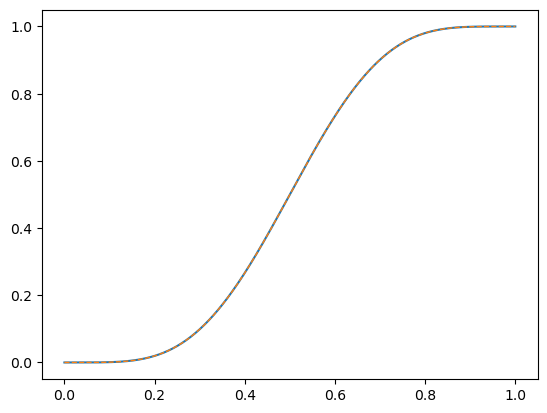

In [20]:
xx = np.linspace(0,1,1000)
a, b = 5,5 

plt.plot(xx, sc.betainc(a,b,xx))
plt.plot(xx, np.exp(pdfs.lnbetainc(a,b,xx)), ls='--', lw=1)

## check MDC results

In [3]:
# truth

truths_dict = {
    "$\\alpha$": 4,
    "$\\delta_m$": 5,
    "$m_{\\min}$": 5,
    "$\\beta$": 1.5,
    "$\\mu_{\\chi}$": 0.05,
    "$\\sigma_{\\chi}$": 10**(-0.85),
    "$\\lambda_p$": 0.04,
    "$\\mu_p$": 35,
    "$\\sigma_p$": 4,
    "$\\gamma$": 3
}

alpha=4
mmin = 5
mmax=50
delta_m=5

lam = 0.04
mpp, sigpp = 35, 4

### initial result with narrow mmin prior

In [52]:
backend = HDFBackend('/data/aqc/rjmcmc_pop/results/MDC_test/backend_bad_mmin_prior.h5')
print(backend.branch_names)
print(backend.shape)

['local' 'global']
{'local': (np.int64(5), np.int64(60), np.int64(5), np.int64(7)), 'global': (np.int64(5), np.int64(60), np.int64(1), np.int64(1))}


In [6]:
logl = backend.get_log_like()
print(logl.shape)
print(np.amax(logl))

(7500, 5, 60)
-1664.4504155852107


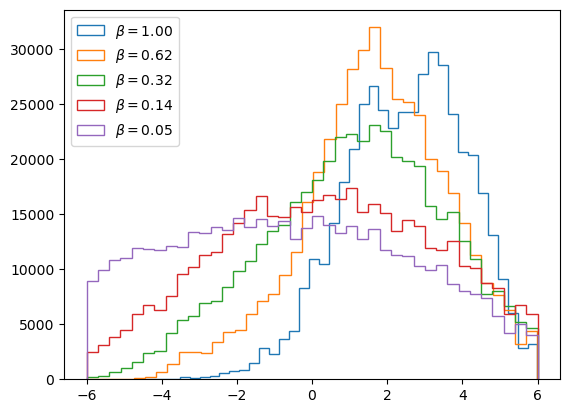

In [7]:
# check chain convergence of global parameter (gamma)
samples_global_all = backend.get_chain()['global']
beta_mean = np.mean(backend.get_betas(), axis=0)
for i in range(samples_global_all.shape[1]):
    _ = plt.hist(samples_global_all[:, i].flatten(), histtype='step', bins=40, label=f'$\\beta={beta_mean[i]:.2f}$')
plt.legend()

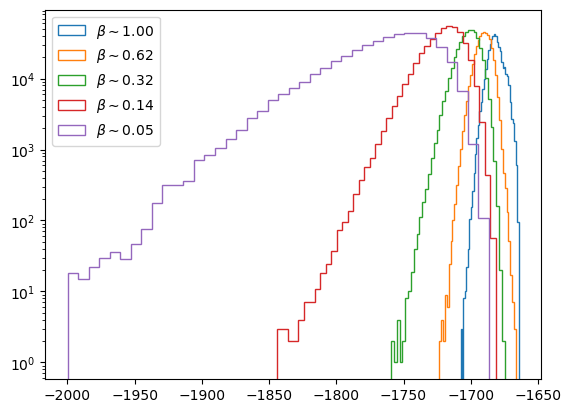

In [8]:
# check log likelihood convergence
for i in range(logl.shape[1]):
    logl_temp = logl[:, i].flatten()
    logl_temp = logl_temp[logl_temp > -2000]
    _ = plt.hist(logl_temp, histtype='step', bins=40, label=f'$\\beta \sim {beta_mean[i]:.2f}$', log=True)
plt.legend()

In [53]:
nsamps, ntemps, nwalkers = logl.shape

# check acceptance ratios
print(backend.swaps_accepted / (nsamps*nwalkers)) # swap acceptance ratio
print(np.mean(backend.accepted[0]) / nsamps) # average within-temp acceptance ratio across walkers in beta=1
print(np.mean(backend.rj_accepted[0]) / nsamps) # average RJ within-temp acceptance ratio across walkers in beta=1

[0.20352    0.20341778 0.20520667 0.20678   ]
0.2650088888888889
0.13655111111111112


(450000, 5, 7)

In [ ]:
# combine walkers
samples_local = backend.get_chain()['local'][:,0].reshape(nsamps*nwalkers, 5, 7)
print(samples_local.shape)

# sort by mmin 

mmin_ind = 2
mmins = np.array(samples_local[..., mmin_ind])
mmins[np.isnan(mmins)] = np.inf
sorted_inds_ncomp = np.argsort(mmins, axis=-1) # just need to sort the subpopulations
sorted_inds_samples = np.broadcast_to(np.arange(sorted_inds_ncomp.shape[0])[:, None], sorted_inds_ncomp.shape)
samples_local_sorted = samples_local[sorted_inds_samples, sorted_inds_ncomp]

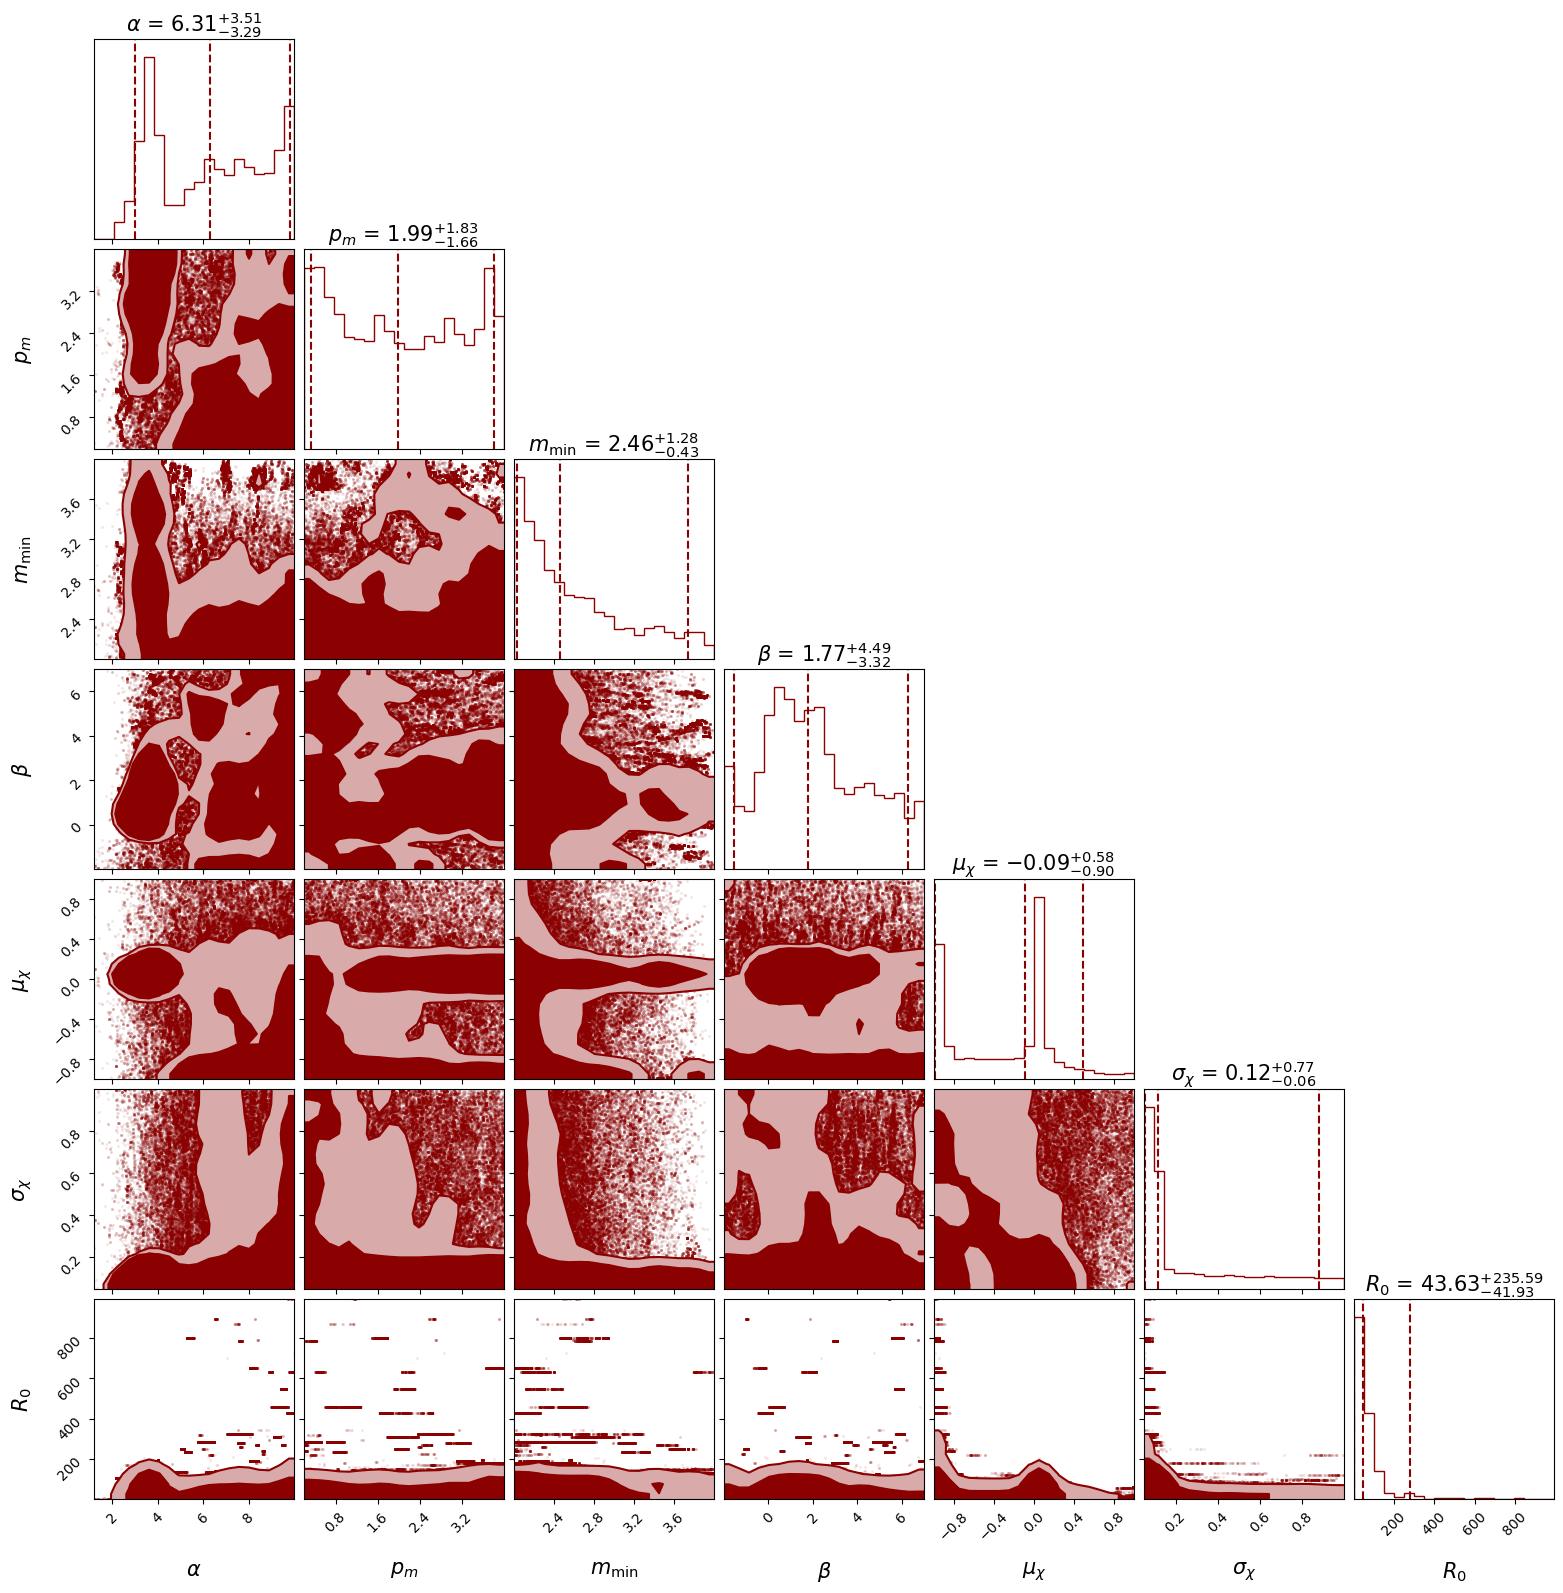

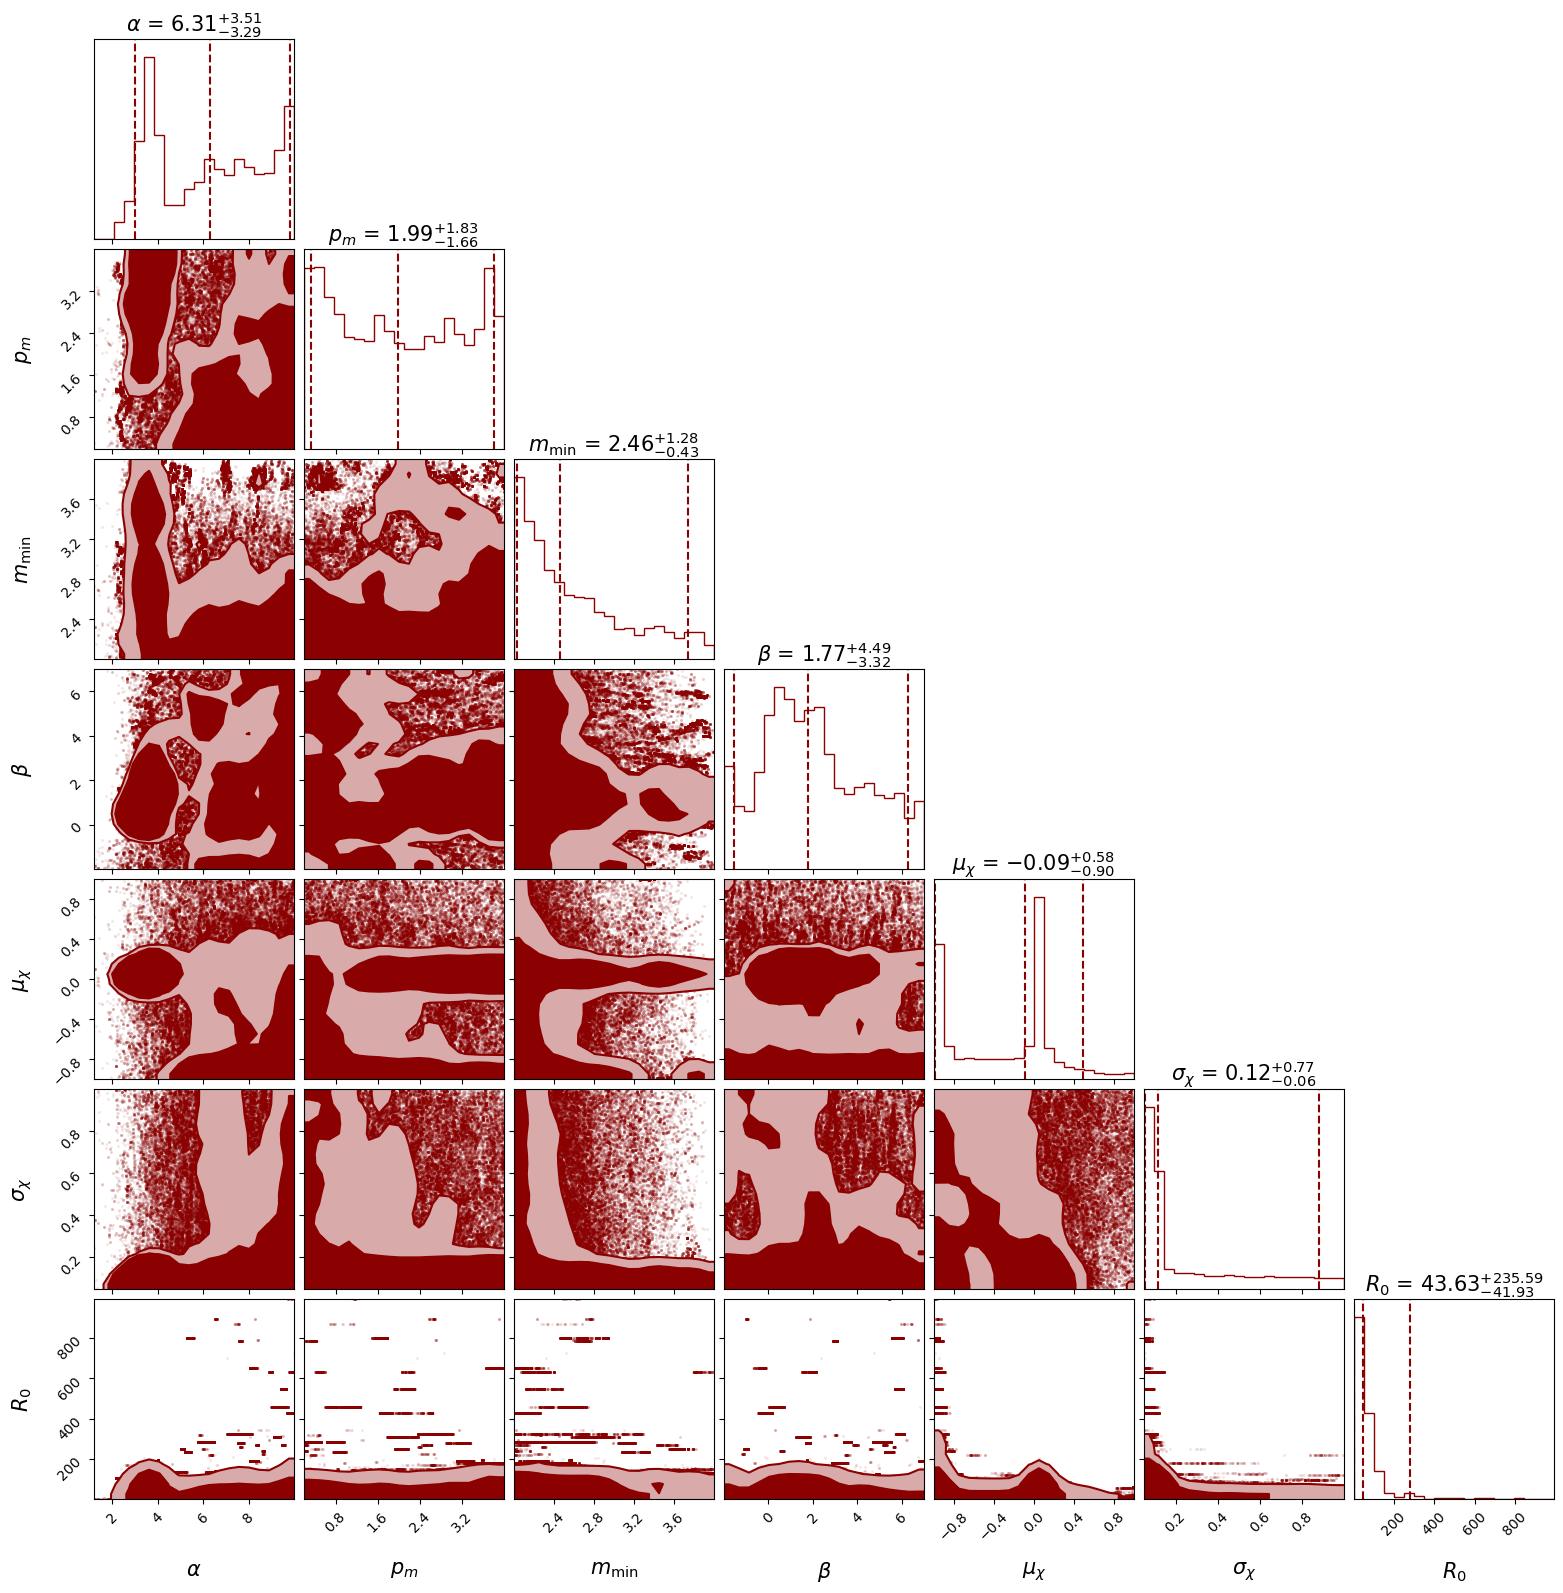

In [ ]:
# now let's check the first / main subpopulation 

latex_labels = [
        "$\\alpha$",
        "$p_m$",
        "$m_{\\min}$",
        "$\\beta$",
        "$\\mu_{\\chi}$",
        "$\\sigma_{\\chi}$",
        "$R_0$"
    ]

corner.corner(samples_local_sorted[:,0,:], labels=latex_labels, **corner_defaults)

In [ ]:
# let's look at the mass population?

mm = np.linspace(0, 100, 1001)
mm_cp = cp.array(mm)
ndraws = 500

rand_inds = np.random.randint(0, len(samples_local_sorted), size=(ndraws,))
rand_samples_local_sorted = cp.array(samples_local_sorted[rand_inds])

component_pdfs = pdfs.smoothed_powerlaw.pdf(
    mm_cp, 
    alpha=rand_samples_local_sorted[..., 0, None],
    p=rand_samples_local_sorted[..., 1, None],
    xmin=rand_samples_local_sorted[..., 2, None],
    xmax=300.0,
)

component_pdfs[~cp.isfinite(component_pdfs)] = 0.0

R0s = cp.array(rand_samples_local_sorted[..., -1])
R0s[~cp.isfinite(R0s)] = 0.0

per_comp_rate = (R0s[..., None] * component_pdfs).get()
tot_rate = np.sum(per_comp_rate, axis=1)
tot_pdf = tot_rate / np.trapezoid(tot_rate, mm, axis=1)[:,None]

In [ ]:

ncomp = samples_local_sorted.shape[1]
colors = sns.color_palette("flare", ncomp)
colors

[(0.91262605, 0.52893336, 0.40749715),
 (0.87199254, 0.3633634, 0.35974223),
 (0.75861834, 0.25356035, 0.40663694),
 (0.60407977, 0.21017746, 0.43913439),
 (0.44584668, 0.17360625, 0.43114133)]

In [33]:
per_comp_rate.shape

(500, 5, 101)

(0.001, np.float64(212.8675911358753))

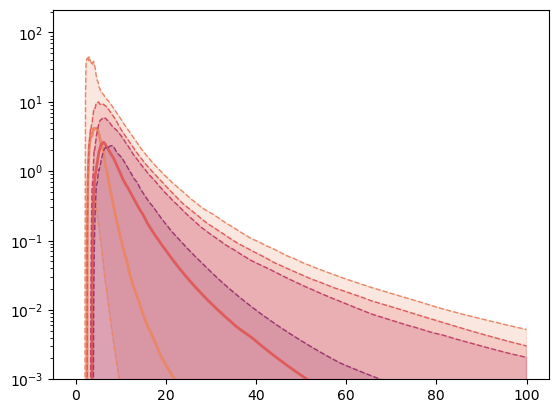

In [44]:
# plot components

for i, color in enumerate(colors):
    low, med, high = np.percentile(per_comp_rate[:,i], [10, 50, 90], axis=0)
    plt.plot(mm, med, lw=2, color=color)
    plt.plot(mm, low, color=color, lw=1, ls='--')
    plt.plot(mm, high, color=color, lw=1, ls='--')
    plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.yscale('log')
plt.ylim(bottom=1e-3)

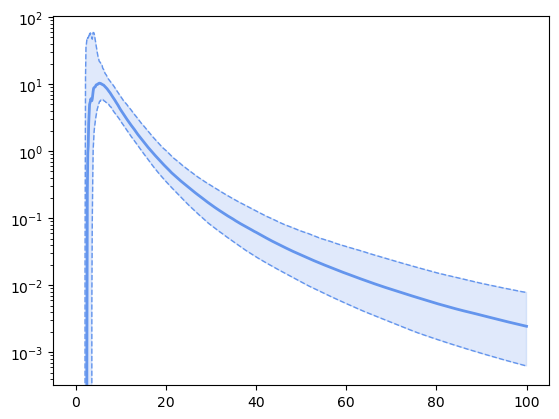

In [45]:
# plot total

low, med, high = np.percentile(tot_rate, [10, 50, 90], axis=0)
color='cornflowerblue'

plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.yscale('log')

(1e-05, np.float64(2.4442125876318723))

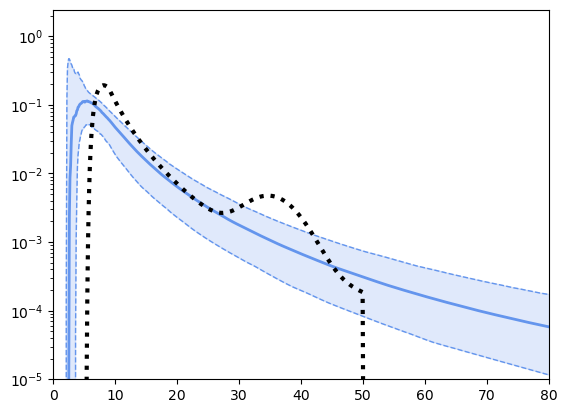

In [50]:
# compare with truth
alpha=4
mmin = 5
mmax=50
delta_m=5

lam = 0.04
mpp, sigpp = 35, 4

truth_pdf = (1-lam)*pdfs.LVK_Plancktaper_powerlaw.pdf(
    mm_cp, alpha=alpha, xmin=mmin, xmax=mmax, delta=delta_m
) + lam*pdfs.gaussian.pdf(
    mm_cp, loc=mpp, scale=sigpp, xmin=mmin, xmax=mmax
)
truth_pdf = truth_pdf.get()

low, med, high = np.percentile(tot_pdf, [10, 50, 90], axis=0)

plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.plot(mm, truth_pdf, lw=3, color='k', ls='dotted')

plt.yscale('log')
plt.xlim(0, 80)
plt.ylim(bottom=1e-5)

### LVK PLP testing on MDC

In [4]:
backend = HDFBackend('/data/aqc/rjmcmc_pop/results/MDC_PLP/backend_out.h5')
with open('/data/aqc/rjmcmc_pop/results/MDC_PLP/ordered_hyperparameter_latex.json', 'r') as f:
    ordered_latex_hp_names = json.load(f)

In [5]:
logl = backend.get_log_like()
print(logl.shape)
print(np.amax(logl))

# check log posterior convergence
logP = backend.get_log_posterior()
print(np.sum(logP > -1e300) / logP.size)

(1000, 8, 100)
-1597.6397075711666
1.0


(-1700.0, -1600.0)

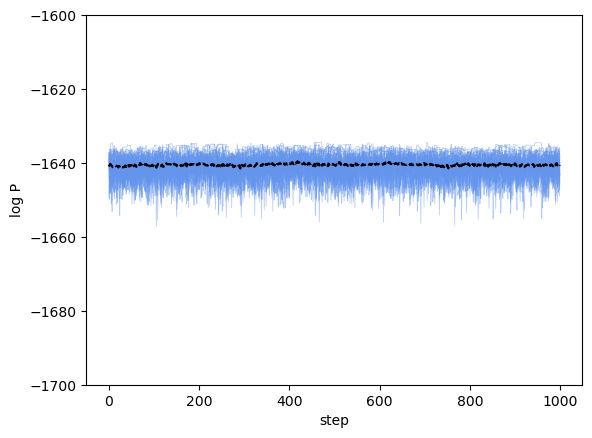

In [6]:
n_walkers_plot = 40 # plot twenty walkers
rand_inds = np.random.choice(logP.shape[-1], size=n_walkers_plot, replace=False)
for i in rand_inds: # iterate through all walkers
    plt.plot(logP[:,0,i], lw=0.5, alpha=0.5, color='cornflowerblue')
plt.plot(np.mean(logP[:,0], axis=-1), color='k', ls='--')
plt.ylabel('log P')
plt.xlabel('step')

plt.ylim(-1700, -1600)

In [7]:
# no discard needed
discard = 0

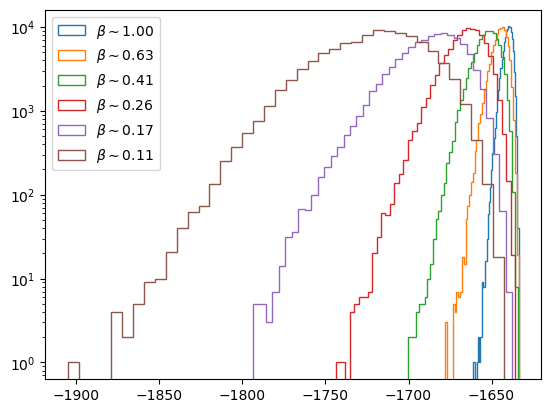

In [8]:
# check log likelihood convergence with temperature
logP = backend.get_log_posterior(discard=discard)

beta_mean = np.mean(backend.get_betas(), axis=0)
for i in range(logP.shape[1]-2):
    logP_temp = logP[:, i].flatten()
    logP_temp = logP_temp[logP_temp > -2000]
    _ = plt.hist(logP_temp, histtype='step', bins=40, label=f'$\\beta \sim {beta_mean[i]:.2f}$', log=True)
plt.legend()

In [9]:
nsamps_tot, ntemps, nwalkers = logl.shape

# check acceptance ratios
print(backend.swaps_accepted / (nsamps_tot*nwalkers)) # swap acceptance ratio
print(np.mean(backend.accepted[0]) / nsamps_tot) # average within-temp acceptance ratio across walkers in beta=1
# print(np.mean(backend.rj_accepted[0]) / nsamps_tot) # average RJ within-temp acceptance ratio across walkers in beta=1

[0.36064 0.35432 0.34799 0.33755 0.33399 0.33692 0.33443]
0.43961


In [10]:
ordered_latex_hp_names

[['$\\alpha$',
  '$\\delta_m$',
  '$m_{\\min}$',
  '$\\beta$',
  '$\\mu_{\\chi}$',
  '$\\sigma_{\\chi}$',
  '$R_0$'],
 ['$\\mu_p$',
  '$\\sigma_p$',
  '$\\beta$',
  '$\\mu_{\\chi}$',
  '$\\sigma_{\\chi}$',
  '$R_0$'],
 ['$\\gamma$', '$m_{\\min}^{\\text{global}}$']]

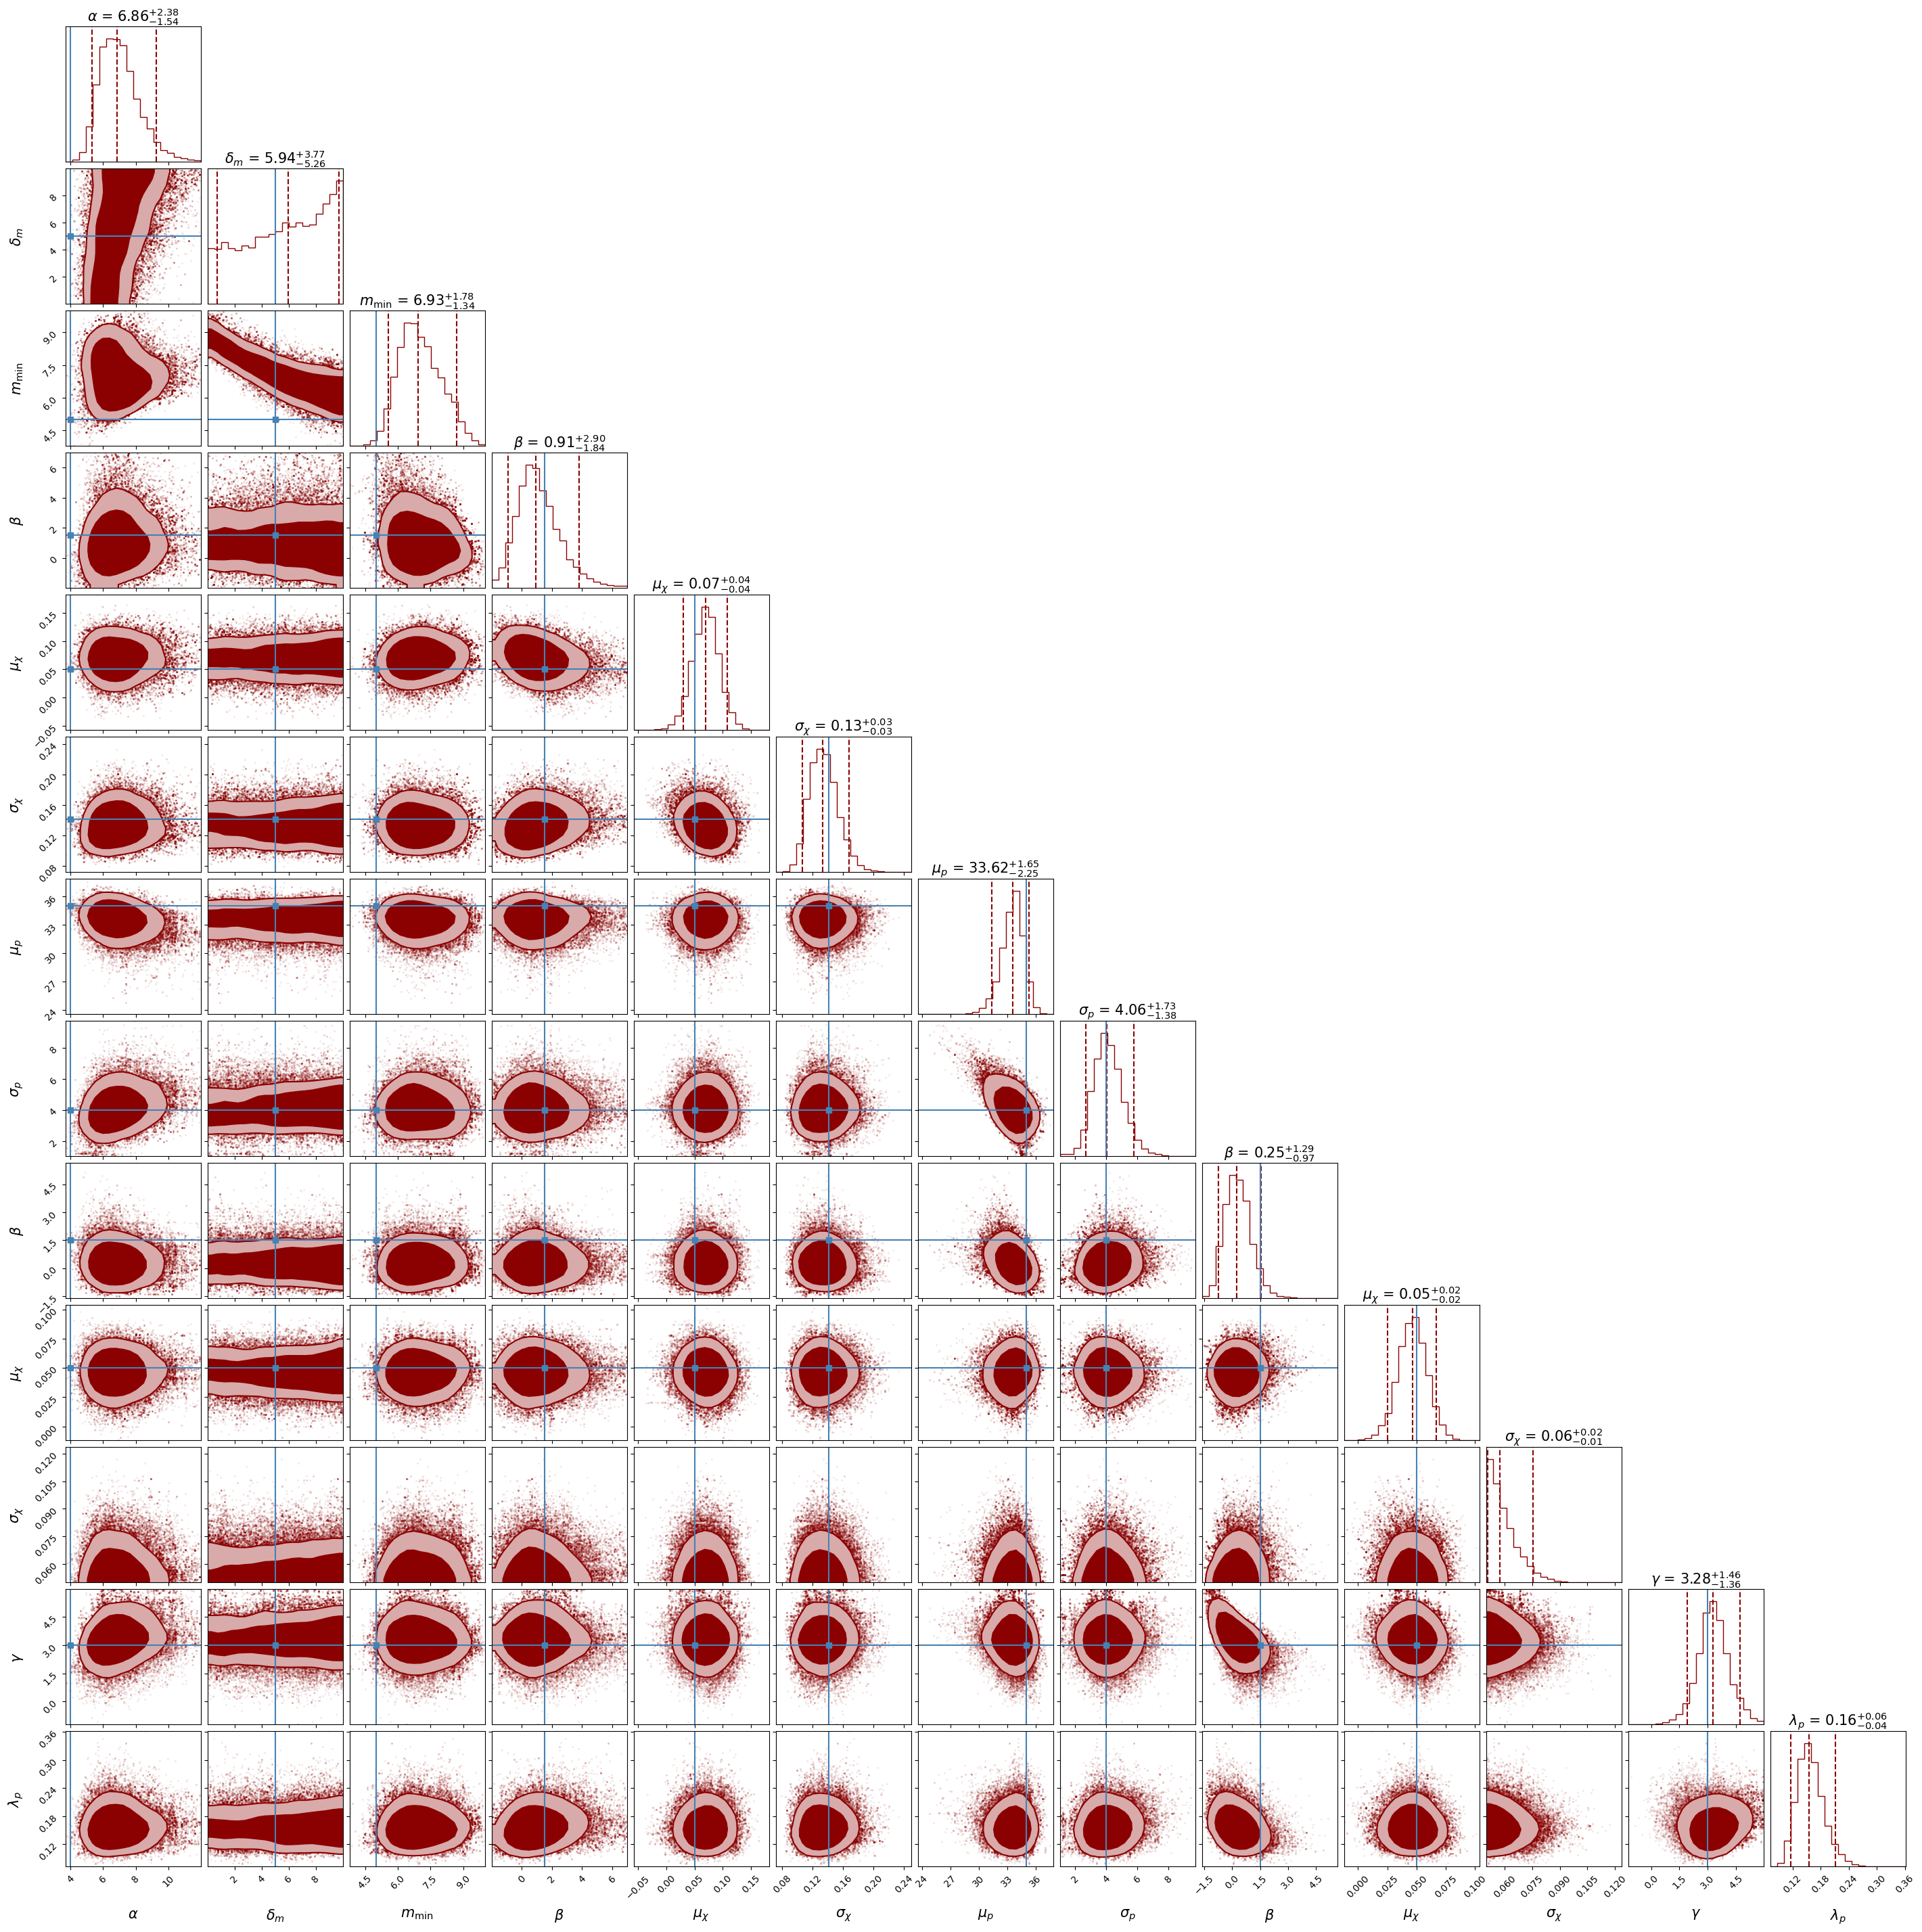

In [11]:
# big corner plot

R0_PL = backend.get_chain(discard=discard)['PL'][:, 0, ..., -1]
R0_gauss = backend.get_chain(discard=discard)['gauss'][:, 0, ..., -1]

lam_p = R0_gauss / (R0_gauss + R0_PL)

all_samples = np.concatenate(
    (
        backend.get_chain(discard=discard)['PL'][:, 0, ..., :-1], 
        backend.get_chain(discard=discard)['gauss'][:, 0, ..., :-1], # exclude R0
        backend.get_chain(discard=discard)['global'][:, 0, ..., :-1], # exclude global mmin parameter
        lam_p[..., None]
    ), axis=-1
)
all_samples = all_samples.reshape(-1, all_samples.shape[-1])


all_latex_names = ordered_latex_hp_names[0][:-1] + ordered_latex_hp_names[1][:-1] + ordered_latex_hp_names[-1][:-1] + [r'$\lambda_p$']
truths = [truths_dict[k] for k in all_latex_names]

corner.corner(all_samples, labels=all_latex_names, truths=truths, **corner_defaults)
plt.show()

In [12]:
del all_samples, logl, logP

In [ ]:
mm = np.linspace(0, 100, 1001)
mm_cp = cp.array(mm)
ndraws = 500
shape = backend.shape

PL_samples = backend.get_chain(discard=discard)['PL'][:, 0].reshape((-1, shape['PL'][-1]))
gauss_samples = backend.get_chain(discard=discard)['gauss'][:, 0].reshape((-1, shape['gauss'][-1]))
mmin_glob = backend.get_chain(discard=discard)['global'][:, 0, ..., -1].flatten()

rand_inds = np.random.randint(0, len(mmin_glob), size=(ndraws,))
PL_samples = cp.array(PL_samples[rand_inds])
gauss_samples = cp.array(gauss_samples[rand_inds])
mmin_glob = cp.array(mmin_glob[rand_inds])

In [15]:
inferred_rate = PL_samples[..., -1, None] * pdfs.LVK_Plancktaper_powerlaw.pdf(
    mm_cp, 
    alpha=PL_samples[..., 0, None],
    delta=PL_samples[..., 1, None],
    xmin=PL_samples[..., 2, None],
    xmax=300.0,
) + gauss_samples[..., -1, None] * pdfs.gaussian.pdf(
    mm_cp, 
    loc=gauss_samples[..., 0, None], 
    scale=gauss_samples[..., 1, None],
    xmin=mmin_glob[:,None],
    xmax=300.0,
)
inferred_rate = inferred_rate.get()
inferred_pdf = inferred_rate / np.trapezoid(inferred_rate, mm, axis=1)[:,None]

# truth pdf
truth_pdf = (1-lam)*pdfs.LVK_Plancktaper_powerlaw.pdf(
    mm_cp, alpha=alpha, xmin=mmin, xmax=mmax, delta=delta_m
) + lam*pdfs.gaussian.pdf(
    mm_cp, loc=mpp, scale=sigpp, xmin=mmin, xmax=mmax
)
truth_pdf = truth_pdf.get()

(0.0, 70.0)

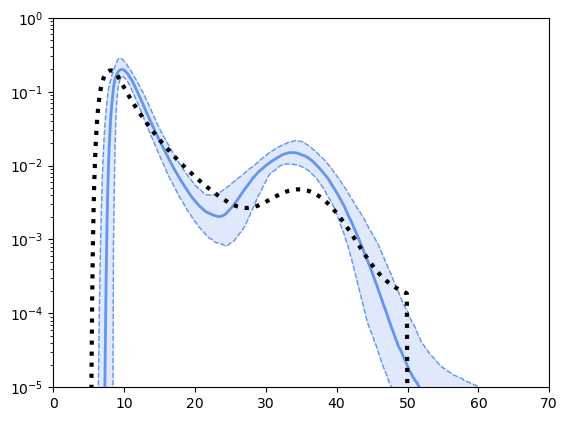

In [16]:
# compare total with truth

low, med, high = np.percentile(inferred_pdf, [10, 50, 90], axis=0)
color='cornflowerblue'

plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.plot(mm, truth_pdf, lw=3, color='black', ls='dotted')

plt.yscale('log')
plt.ylim(1e-5, 1)
plt.xlim(0, 70)

### logl PLP+

In [3]:
backend = HDFBackend('/data/aqc/rjmcmc_pop/results/MDC_test/backend_PLP.h5')
with open('/data/aqc/rjmcmc_pop/results/MDC_test/ordered_hyperparameter_latex.json', 'r') as f:
    ordered_latex_hp_names = json.load(f)

In [4]:
logl = backend.get_log_like()
print(logl.shape)
print(np.amax(logl))

(2000, 8, 70)
-1625.6040057613664


Text(0.5, 0, 'step')

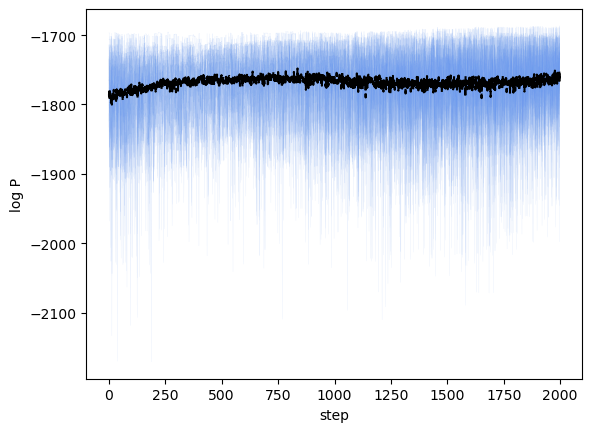

In [9]:
# check log posterior convergence
logP = backend.get_log_posterior()

n_walkers_plot = 20 # plot twenty walkers
rand_inds = np.random.choice(logP.shape[-1], size=n_walkers_plot, replace=False)
for i in rand_inds: # iterate through all walkers
    plt.plot(logP[:,0,i], lw=0.2, alpha=0.2, color='cornflowerblue')
plt.plot(np.mean(logP[:,0], axis=-1), color='k', ls='--')
plt.ylabel('log P')
plt.xlabel('step')

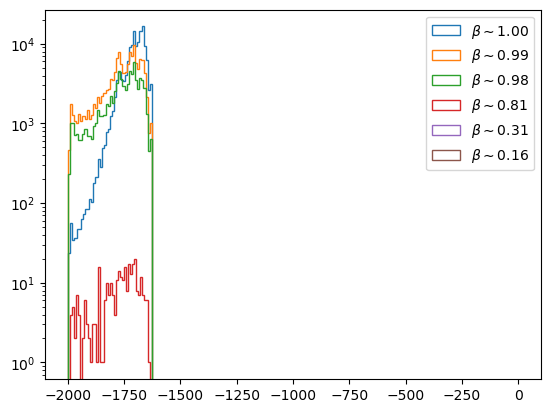

In [ ]:
# check log likelihood convergence with temperature
beta_mean = np.mean(backend.get_betas(), axis=0)
for i in range(logl.shape[1]-2):
    logl_temp = logl[:, i].flatten()
    logl_temp = logl_temp[logl_temp > -2000]
    _ = plt.hist(logl_temp, histtype='step', bins=40, label=f'$\\beta \sim {beta_mean[i]:.2f}$', log=True)
plt.legend()

In [8]:
nsamps, ntemps, nwalkers = logl.shape

# check acceptance ratios
print(backend.swaps_accepted / (nsamps*nwalkers)) # swap acceptance ratio
print(np.mean(backend.accepted[0]) / nsamps) # average within-temp acceptance ratio across walkers in beta=1
print(np.mean(backend.rj_accepted[0]) / nsamps) # average RJ within-temp acceptance ratio across walkers in beta=1

[0.52714286 0.53832857 0.41270714 0.99758571 0.99997857 0.99998571
 0.99997857]
0.37603571428571425
0.5247714285714286


In [18]:
shape = backend.shape
shape

{'PL': (np.int64(8), np.int64(70), np.int64(1), np.int64(7)),
 'gauss': (np.int64(8), np.int64(70), np.int64(5), np.int64(6)),
 'global': (np.int64(8), np.int64(70), np.int64(1), np.int64(2))}

In [19]:
ordered_latex_hp_names

[['$\\alpha$',
  '$p_m$',
  '$m_{\\min}$',
  'beta',
  '$\\mu_{\\chi}$',
  '$\\sigma_{\\chi}$',
  '$R_0$'],
 ['$\\mu_p$',
  '$\\sigma_p$',
  'beta',
  '$\\mu_{\\chi}$',
  '$\\sigma_{\\chi}$',
  '$R_0$'],
 ['$\\gamma$', '$m_{\\min}^{\\text{global}}$']]

In [17]:
backend.get_chain()['PL'].shape

(2000, 8, 70, 1, 7)

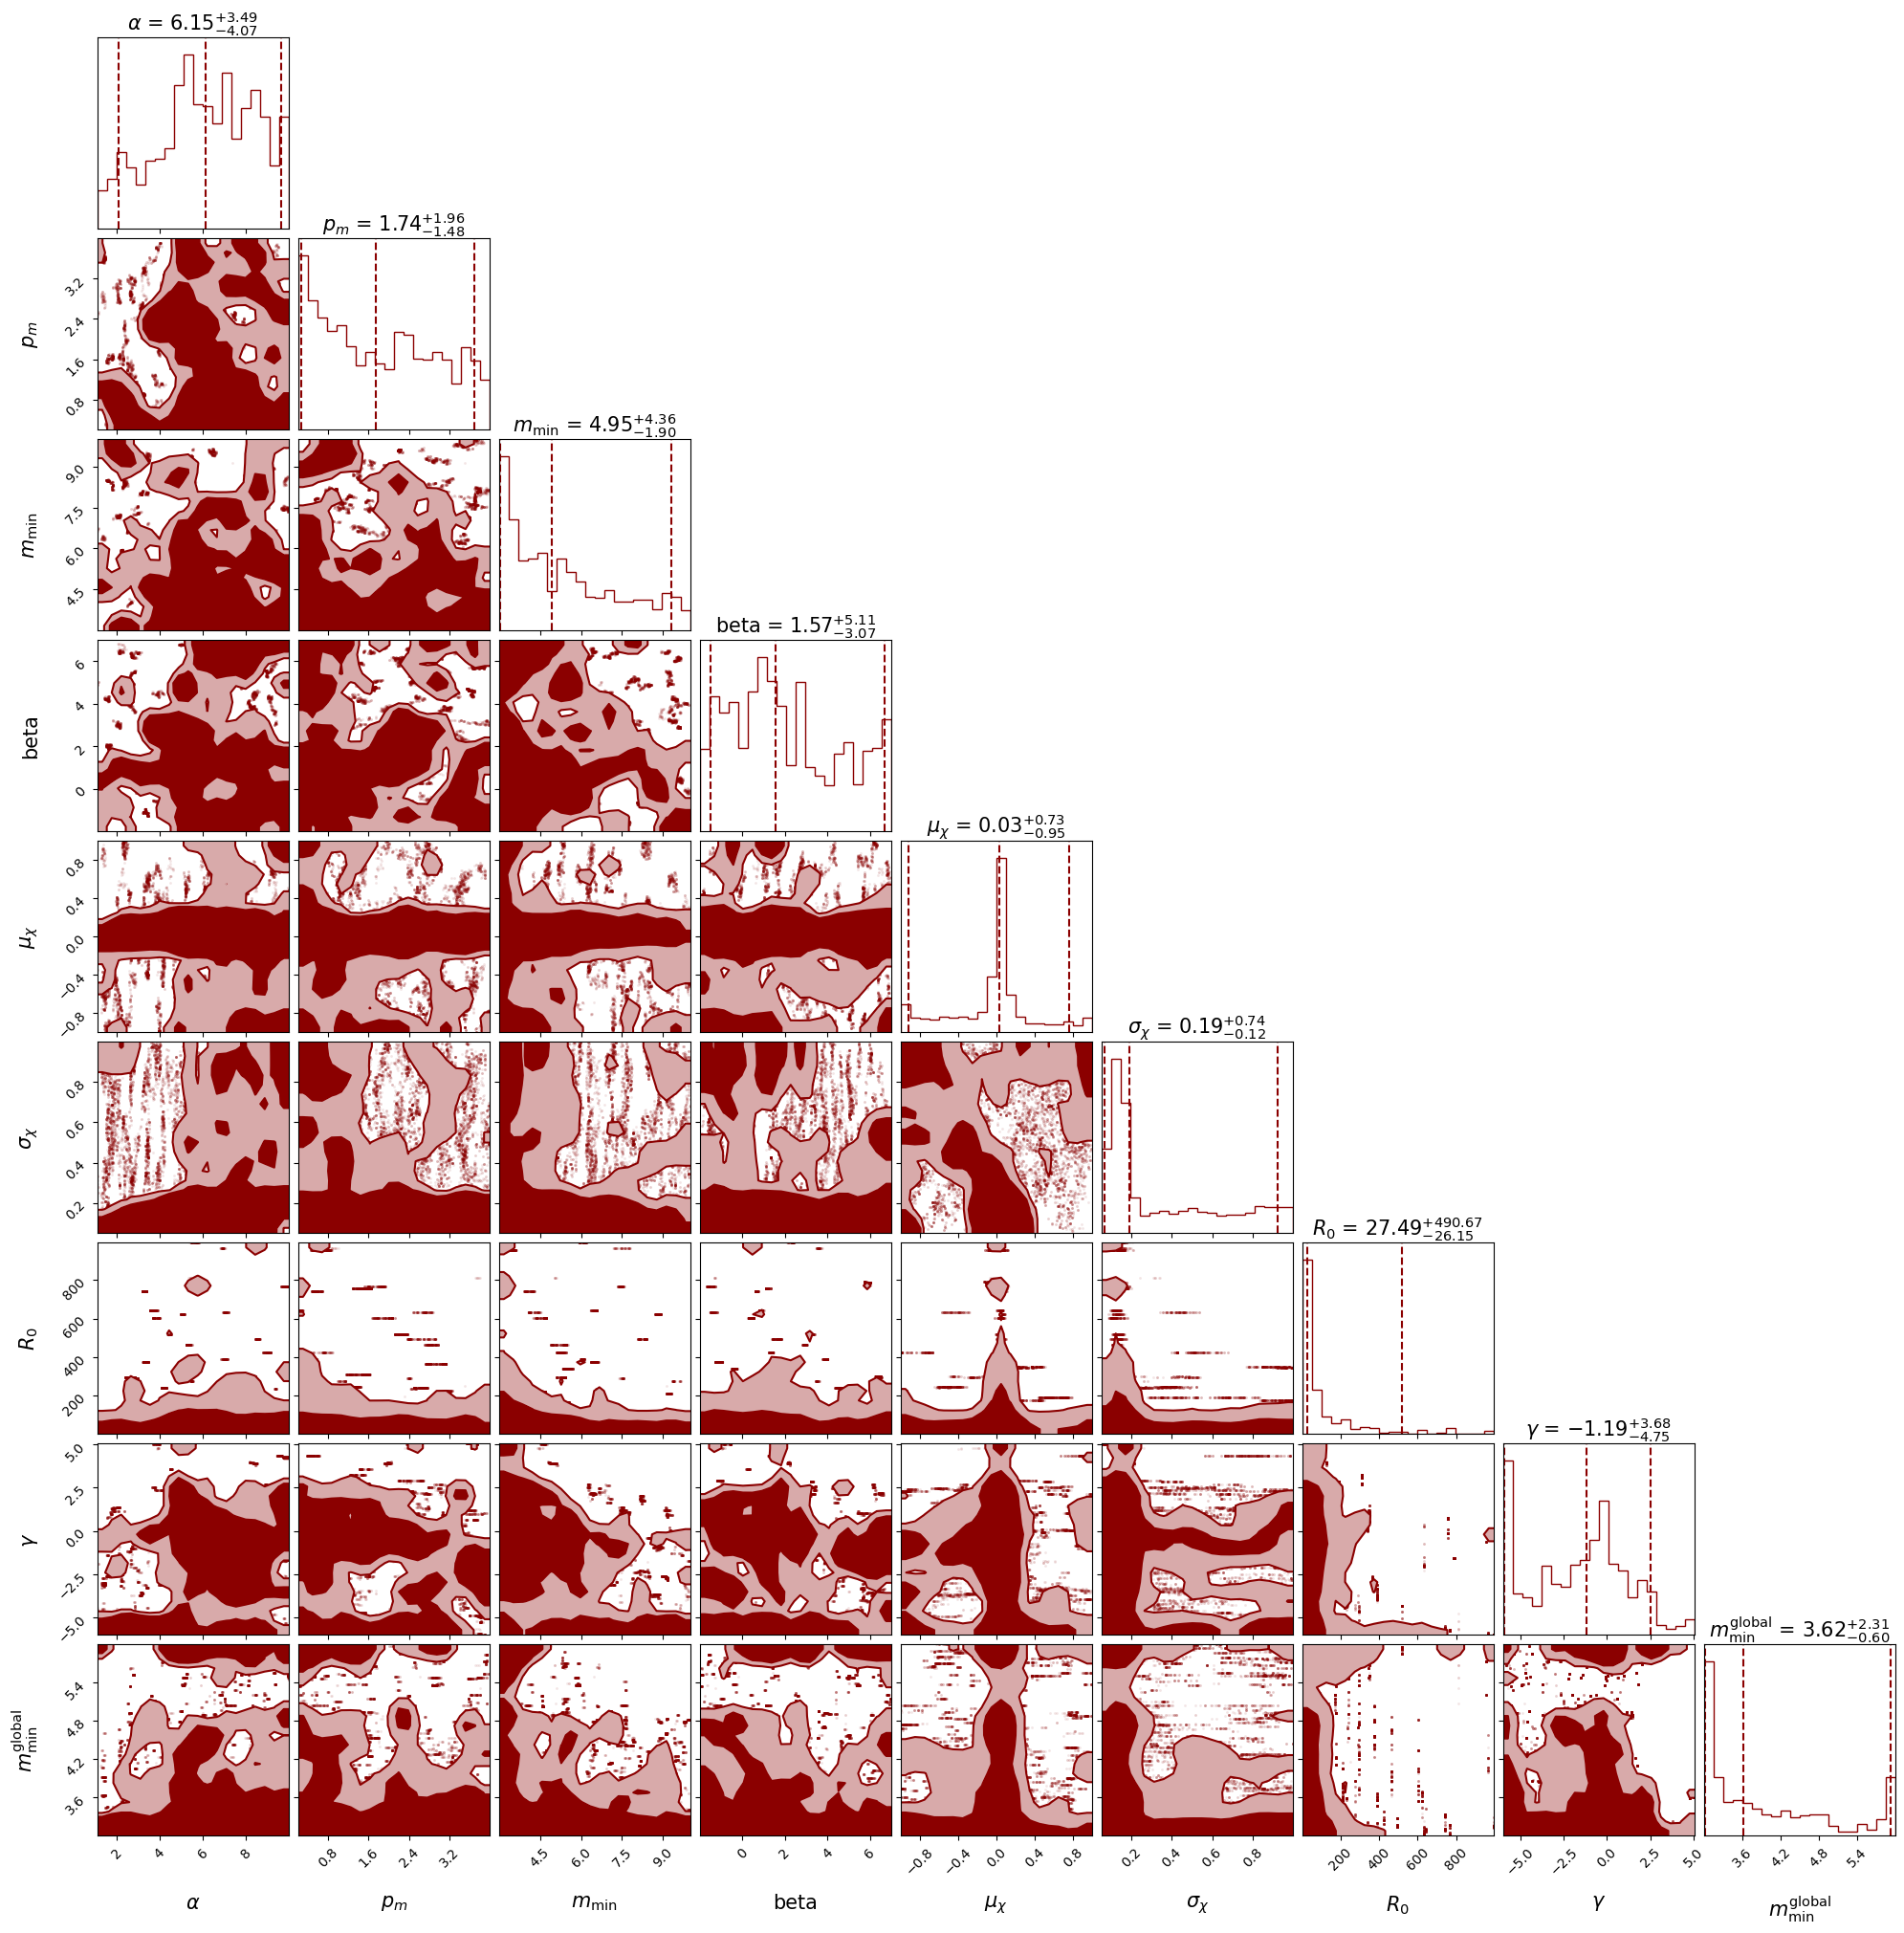

In [20]:
# check main PL branch params

discard = 1000
nsamps -= discard

PL_component_samps = np.concatenate((backend.get_chain()['PL'][discard:, 0], backend.get_chain()['global'][discard:, 0]), axis=-1)
PL_component_samps = PL_component_samps.reshape(-1, PL_component_samps.shape[-1])

PL_component_latex_names = ordered_latex_hp_names[0] + ordered_latex_hp_names[-1]

corner.corner(PL_component_samps, labels=PL_component_latex_names, **corner_defaults)
plt.show()

In [5]:
# get truth

alpha=4
mmin = 5
mmax=50
delta_m=5

lam = 0.04
mpp, sigpp = 35, 4

In [6]:
shape = backend.shape
print(shape)

# combine walkers
ntepms, nwalkers, ncomp, ndim = shape['gauss']
samples_gauss = backend.get_chain()['gauss'][:,0].reshape(-1, ncomp, ndim)

# sort by mmin 
mmin_ind = 2
mmins = np.array(samples_gauss[..., mmin_ind])
mmins[np.isnan(mmins)] = np.inf
sorted_inds_ncomp = np.argsort(mmins, axis=-1) # just need to sort the subpopulations
sorted_inds_samples = np.broadcast_to(np.arange(sorted_inds_ncomp.shape[0])[:, None], sorted_inds_ncomp.shape)
samples_gauss_sorted = samples_gauss[sorted_inds_samples, sorted_inds_ncomp]

{'PL': (np.int64(8), np.int64(70), np.int64(1), np.int64(7)), 'gauss': (np.int64(8), np.int64(70), np.int64(5), np.int64(6)), 'global': (np.int64(8), np.int64(70), np.int64(1), np.int64(2))}


(0.0, 70.0)

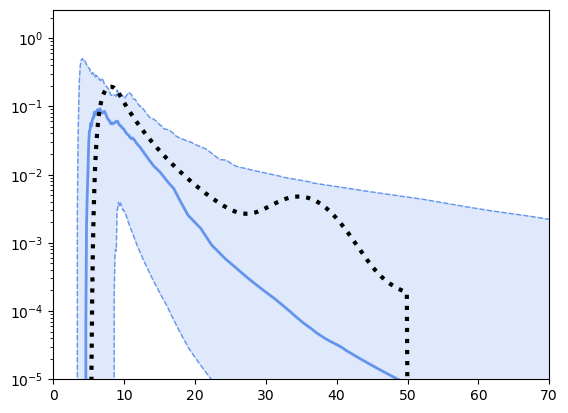

In [9]:
# plot the powerlaw

mm = np.linspace(0, 100, 1001)
mm_cp = cp.array(mm)
ndraws = 500

rand_inds = np.random.randint(0, nsamps, size=(ndraws,))

PL_samples = backend.get_chain()['PL'][:, 0].reshape((-1, shape['PL'][-1]))
PL_samples_rand = cp.array(PL_samples[rand_inds])

component_pdfs = pdfs.smoothed_powerlaw.pdf(
    mm_cp, 
    alpha=PL_samples_rand[..., 0, None],
    p=PL_samples_rand[..., 1, None],
    xmin=PL_samples_rand[..., 2, None],
    xmax=300.0,
).get()
component_pdfs /= np.trapezoid(component_pdfs, mm, axis=1)[:,None]

# truth pdf
truth_pdf = (1-lam)*pdfs.LVK_Plancktaper_powerlaw.pdf(
    mm_cp, alpha=alpha, xmin=mmin, xmax=mmax, delta=delta_m
) + lam*pdfs.gaussian.pdf(
    mm_cp, loc=mpp, scale=sigpp, xmin=mmin, xmax=mmax
)
truth_pdf = truth_pdf.get()

# plot total

low, med, high = np.percentile(component_pdfs, [10, 50, 90], axis=0)
color='cornflowerblue'

plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.plot(mm, truth_pdf, lw=3, color='black', ls='dotted')

plt.yscale('log')
plt.ylim(bottom=1e-5)
plt.xlim(0, 70)

In [10]:
# let's look at the gaussians now

mmin_glob = backend.get_chain()['global'][:,0][..., -1].flatten()

rand_samples_gauss_sorted = cp.array(samples_gauss_sorted[rand_inds])
mmin_glob_rand = cp.array(mmin_glob[rand_inds])

gauss_rate_arr = pdfs.gaussian.pdf(
    mm_cp, 
    loc=rand_samples_gauss_sorted[..., 0, None],
    scale=rand_samples_gauss_sorted[..., 1, None],
    xmin=mmin_glob_rand[..., None, None],
    xmax=300.
)
PL_rate_arr = pdfs.smoothed_powerlaw.pdf(
    mm_cp, 
    alpha=PL_samples_rand[..., 0, None],
    p=PL_samples_rand[..., 1, None],
    xmin=PL_samples_rand[..., 2, None],
    xmax=300.0,
)

gauss_rate_arr[~cp.isfinite(gauss_rate_arr)] = 0.0

R0s = cp.array(rand_samples_gauss_sorted[..., -1])
R0s[~cp.isfinite(R0s)] = 0.0

gauss_rate_arr = (R0s[..., None] * gauss_rate_arr).get()
PL_rate_arr = (PL_samples_rand[..., -1, None] * PL_rate_arr).get()

tot_rate = np.sum(gauss_rate_arr, axis=1) + PL_rate_arr
tot_pdf = tot_rate / np.trapezoid(tot_rate, mm, axis=1)[:,None]

In [11]:
colors = sns.color_palette('flare', shape['gauss'][-2]+1)
colors

[(0.9155979, 0.55210684, 0.42070204),
 (0.888292, 0.40830288, 0.36223756),
 (0.81942908, 0.28911553, 0.38102921),
 (0.69226314, 0.23413578, 0.42480327),
 (0.56041794, 0.19845221, 0.44207535),
 (0.42355299, 0.16934709, 0.42581586)]

(0.001, 20)

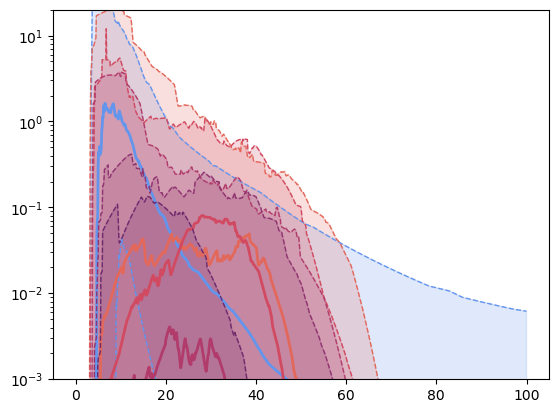

In [ ]:
# plot components

color = 'cornflowerblue' # PL
low, med, high = np.percentile(PL_rate_arr, [10, 50, 90], axis=0)
plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

for i, color in enumerate(colors[1:]):
    low, med, high = np.percentile(gauss_rate_arr[:,i], [10, 50, 90], axis=0)
    plt.plot(mm, med, lw=2, color=color)
    plt.plot(mm, low, color=color, lw=1, ls='--')
    plt.plot(mm, high, color=color, lw=1, ls='--')
    plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.yscale('log')
plt.ylim(1e-3, 100)

(0.0, 70.0)

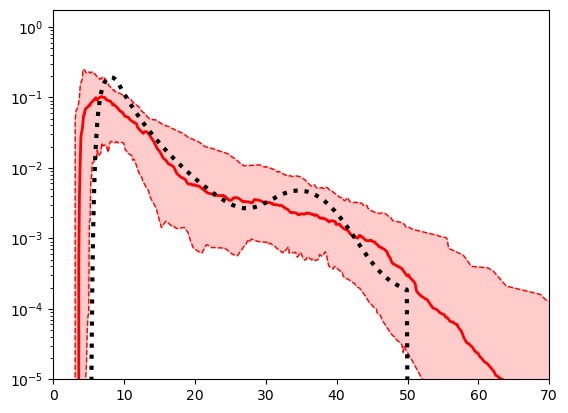

In [12]:
# compare total with truth

low, med, high = np.percentile(tot_pdf, [10, 50, 90], axis=0)
color='red'

plt.plot(mm, med, lw=2, color=color)
plt.plot(mm, low, color=color, lw=1, ls='--')
plt.plot(mm, high, color=color, lw=1, ls='--')
plt.fill_between(mm, low, high, color=color, alpha=0.2)

plt.plot(mm, truth_pdf, lw=3, color='black', ls='dotted')

plt.yscale('log')
plt.ylim(bottom=1e-5)
plt.xlim(0, 70)